In [2]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
df=pd.read_csv(r"D:\weight of copper.csv")
df.head()

,Unnamed: 0,power_rating,weight_of_copper,category
0,0,16.46,34.69,high
1,1,12.52,28.78,high
2,2,7.66,21.48,high
3,3,21.09,41.64,high
4,4,24.43,46.64,high


In [6]:
df=df.drop("Unnamed: 0",axis=1)
df.head()

,power_rating,weight_of_copper,category
0,16.46,34.69,high
1,12.52,28.78,high
2,7.66,21.48,high
3,21.09,41.64,high
4,24.43,46.64,high


In [8]:
K={'low':0,'high':1}
df['category']=df['category'].map(K)
x=df[["power_rating","weight_of_copper"]]
y=df[["category"]]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)
from sklearn.ensemble import RandomForestClassifier
clf=RandomForestClassifier(max_depth=2,random_state=0)
clf.fit(x_train,y_train.values.ravel())

RandomForestClassifier(max_depth=2, random_state=0)

In [10]:
y_pred=clf.predict(x_test)
y_pred

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

In [12]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
print("accuracy score", accuracy_score(y_test,y_pred))
print("mean squared score",mean_squared_error(y_test,y_pred))
from sklearn.metrics import confusion_matrix

accuracy score 1.0
mean squared score 0.0


In [14]:
y_true=y_test
data=confusion_matrix(y_true,y_pred)
data

array([[  3,   0],
       [  0, 162]], dtype=int64)

In [18]:
import seaborn as sn
df_cm=pd.DataFrame(data,columns=np.unique(y_true),index=np.unique(y_true))
df_cm.index_name="Actual"
df_cm.columns_name="Predicted"
plt.figure(figsize=(10,7))
sn.set(font_scale=1.4)
df_cm

,0,1
0,3,0
1,0,162


<Figure size 1000x700 with 0 Axes>

<Axes: >

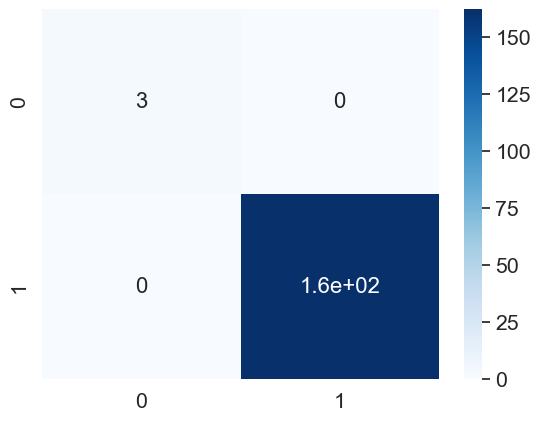

In [20]:
sn.heatmap(df_cm,cmap="Blues",annot=True,annot_kws={"size":16})